**Cell 1: ติดตั้งไลบรารีที่จำเป็น**

In [ ]:
# ติดตั้ง xee (สำหรับเชื่อม Earth Engine กับ xarray) และ geemap
!pip install -q xee geemap xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.4 MB/s eta 0:00:00


**Cell 2: ยืนยันตัวตนและนำเข้าไลบรารี**



In [ ]:
import ee
import geemap
import xarray as xr
import matplotlib.pyplot as plt

# ยืนยันตัวตน (คลิกลิงก์ที่ปรากฏเพื่ออนุญาตการเข้าถึง)
ee.Authenticate()

# กำหนด Project ID ของคุณ (เปลี่ยน 'your-project-id' เป็นชื่อโปรเจกต์ GEE ของคุณ)
# หากคุณใช้บัญชีที่ลงทะเบียนฟรีไว้ อาจจะใช้แค่ ee.Initialize() ก็ได้ครับ
ee.Initialize(project='ee-end-to-end-gee')

**Cell 3: โค้ดวิเคราะห์และแสดงผล 12 เดือน (FacetGrid)**

กำลังเตรียมพารามิเตอร์ Grid และดึงข้อมูลเข้าสู่ Xarray (อาจใช้เวลาสักครู่)...


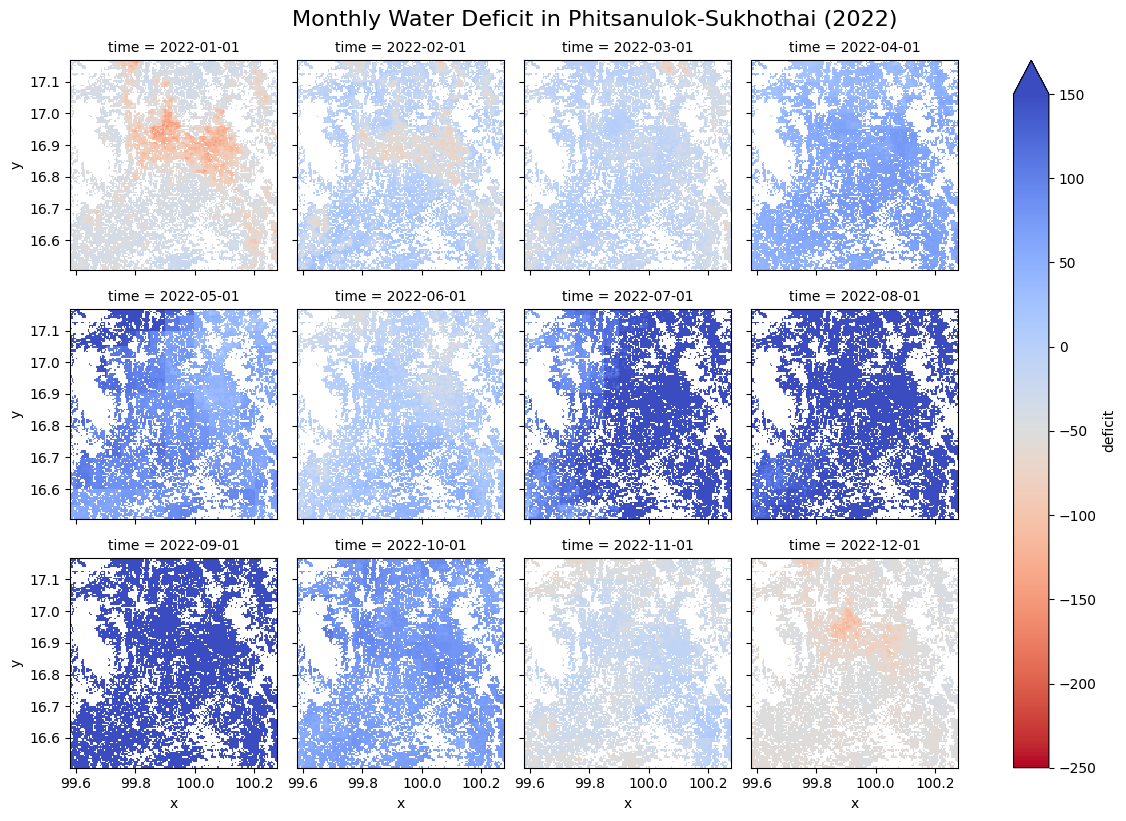


กำลังคำนวณค่าเฉลี่ยรายเดือนและพล็อตกราฟเส้น...


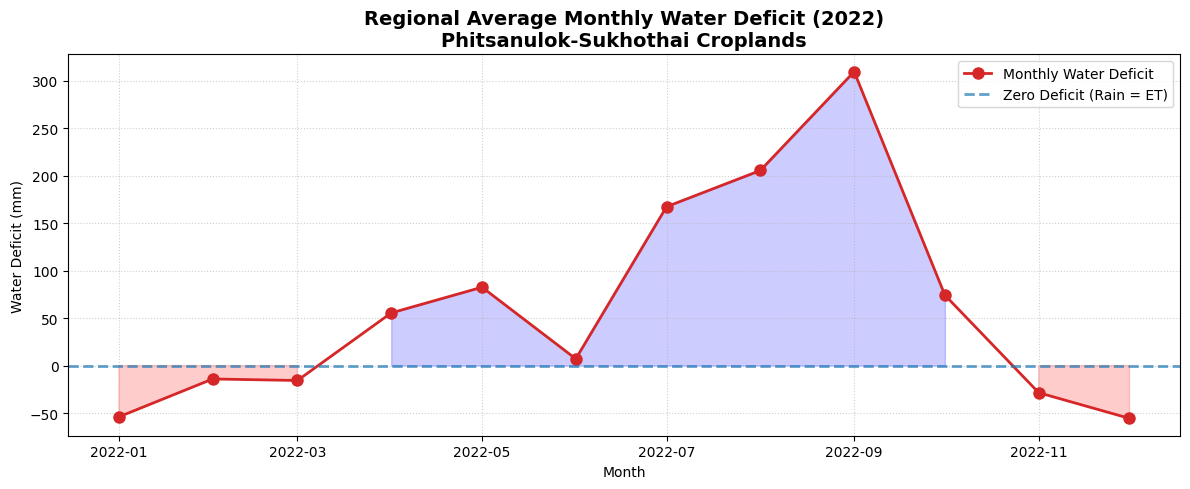

In [ ]:
# เพิ่มไลบรารีใหม่ที่ต้องใช้ตามอัปเดตของ xee v0.1.0+
import shapely
from xee import helpers

# 1. กำหนดพื้นที่ (ROI) และช่วงเวลาหน้าแล้งเพื่อสร้าง Mask
# ใช้ ee.Geometry สำหรับขอบเขตใน Earth Engine
# roi_ee = ee.Geometry.Rectangle([99.897, 16.935, 100.270, 17.224])
roi_ee = ee.Geometry.Rectangle([99.58331572280514,16.509823571011637,100.2753723755851,17.16654821808514])

# 2. สร้าง Mask พื้นที่เกษตร (NDVI > 0.5 และ เป็นพื้นที่ Cropland)
modis_ndvi = ee.ImageCollection("MODIS/061/MOD13A1") \
    .filterDate('2022-01-01', '2022-04-30') \
    .filterBounds(roi_ee).select('NDVI')

ndvi_mask = modis_ndvi.max().multiply(0.0001).gt(0.5)

worldcover = ee.ImageCollection("ESA/WorldCover/v200").first()
crop_mask = worldcover.eq(40)

# รวมหน้ากาก (ใช้ .And() ตัวพิมพ์ใหญ่ สำหรับ Python)
final_mask = ndvi_mask.And(crop_mask)

# 3. สร้างฟังก์ชันคำนวณรายเดือน (ม.ค. - ธ.ค. ปี 2022)
year = 2022
months = ee.List.sequence(1, 12)

def calculateMonthlyDeficit(m):
    start = ee.Date.fromYMD(year, m, 1)
    end = start.advance(1, 'month')

    # อัปเดตเวอร์ชัน MODIS เป็น 061
    et_month = ee.ImageCollection("MODIS/061/MOD16A2") \
        .filterDate(start, end).filterBounds(roi_ee).select('ET') \
        .sum().multiply(0.1)

    pr_month = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
        .filterDate(start, end).filterBounds(roi_ee).select('precipitation') \
        .sum()

    monthly_deficit = pr_month.subtract(et_month) \
        .updateMask(final_mask) \
        .set('system:time_start', start.millis()) \
        .rename('deficit')

    return monthly_deficit

monthly_col = ee.ImageCollection.fromImages(months.map(calculateMonthlyDeficit))

# 4. ดึงข้อมูลเข้าสู่ xarray (ผ่าน Xee Engine เวอร์ชัน 0.1.0+)
print("กำลังเตรียมพารามิเตอร์ Grid และดึงข้อมูลเข้าสู่ Xarray (อาจใช้เวลาสักครู่)...")

# สร้างขอบเขตพื้นที่ด้วย shapely สำหรับ Xarray
# aoi = shapely.geometry.box(99.897, 16.935, 100.270, 17.224)
aoi = shapely.geometry.box(99.58331572280514,16.509823571011637,100.2753723755851,17.16654821808514)

# ใช้ helpers.fit_geometry ของ xee เพื่อสร้าง Grid params (มาตรฐานใหม่)
# ความละเอียด ~500 เมตรในระบบองศา (พิกัด EPSG:4326) จะอยู่ที่ประมาณ 0.0045 องศา
# ระบุแกน y เป็นค่าติดลบ (-0.0045) เพื่อให้ทิศเหนือของภาพอยู่ด้านบนอย่างถูกต้อง
grid_params = helpers.fit_geometry(
    geometry=aoi,
    grid_crs='EPSG:4326',
    grid_scale=(0.0045, -0.0045)
)

# แตก dictionary **grid_params เข้าไปใน open_dataset ตรงๆ
ds = xr.open_dataset(
    monthly_col,
    engine='ee',
    **grid_params
)

# 5. แสดงผลแบบ FacetGrid 12 ช่อง
ds.deficit.plot(
    x='x', y='y',
    col='time', col_wrap=4,
    cmap='coolwarm_r',
    robust=True,
    vmin=-250, vmax=150,
    figsize=(12, 8)
)

plt.suptitle('Monthly Water Deficit in Phitsanulok-Sukhothai (2022)', y=1.02, fontsize=16)
plt.show()

# ========================================================
# 5. การพล็อตกราฟเส้น (Time-Series Line Chart) ภาพรวมพื้นที่
# ========================================================
import matplotlib.pyplot as plt
import pandas as pd

print("\nกำลังคำนวณค่าเฉลี่ยรายเดือนและพล็อตกราฟเส้น...")

# 1. หาค่าเฉลี่ยเชิงพื้นที่ (Spatial Mean) ของพื้นที่แปลงเกษตรทั้งหมด
# ยุบแกน x และ y ทิ้งให้เหลือแค่แกนเวลา (time) แล้วแปลงเป็น DataFrame
regional_deficit = ds.deficit.mean(dim=['x', 'y']).to_dataframe().dropna()

# 2. สร้างกราฟเส้น
plt.figure(figsize=(12, 5))

# พล็อตเส้นค่า Water Deficit
plt.plot(regional_deficit.index, regional_deficit['deficit'],
         marker='o', color='#d62728', linewidth=2, markersize=8, label='Monthly Water Deficit')

# ตีเส้นแนวนอนที่ค่า 0 (Baseline) เพื่อให้ดูง่ายว่าเดือนไหนน้ำขาด/น้ำเกิน
plt.axhline(0, color='#1f77b4', linestyle='--', linewidth=2, alpha=0.7, label='Zero Deficit (Rain = ET)')

# เติมสีใต้กราฟเพื่อเน้นช่วงที่ติดลบ (ขาดแคลนน้ำ)
plt.fill_between(regional_deficit.index, regional_deficit['deficit'], 0,
                 where=(regional_deficit['deficit'] < 0), color='red', alpha=0.2)
plt.fill_between(regional_deficit.index, regional_deficit['deficit'], 0,
                 where=(regional_deficit['deficit'] >= 0), color='blue', alpha=0.2)

# ตกแต่งกราฟ
plt.title('Regional Average Monthly Water Deficit (2022)\nPhitsanulok-Sukhothai Croplands', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Water Deficit (mm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

**เปรียบเทียบ Monthly Water Deficit (2020 vs 2022)**

กำลังสร้างหน้ากากพื้นที่แปลงเกษตร (Cropland Mask)...
กำลังเตรียมพารามิเตอร์ Grid และดึงข้อมูลปี 2020 เข้าสู่ Xarray (อาจใช้เวลาสักครู่)...
กำลังพล็อตแผนที่...


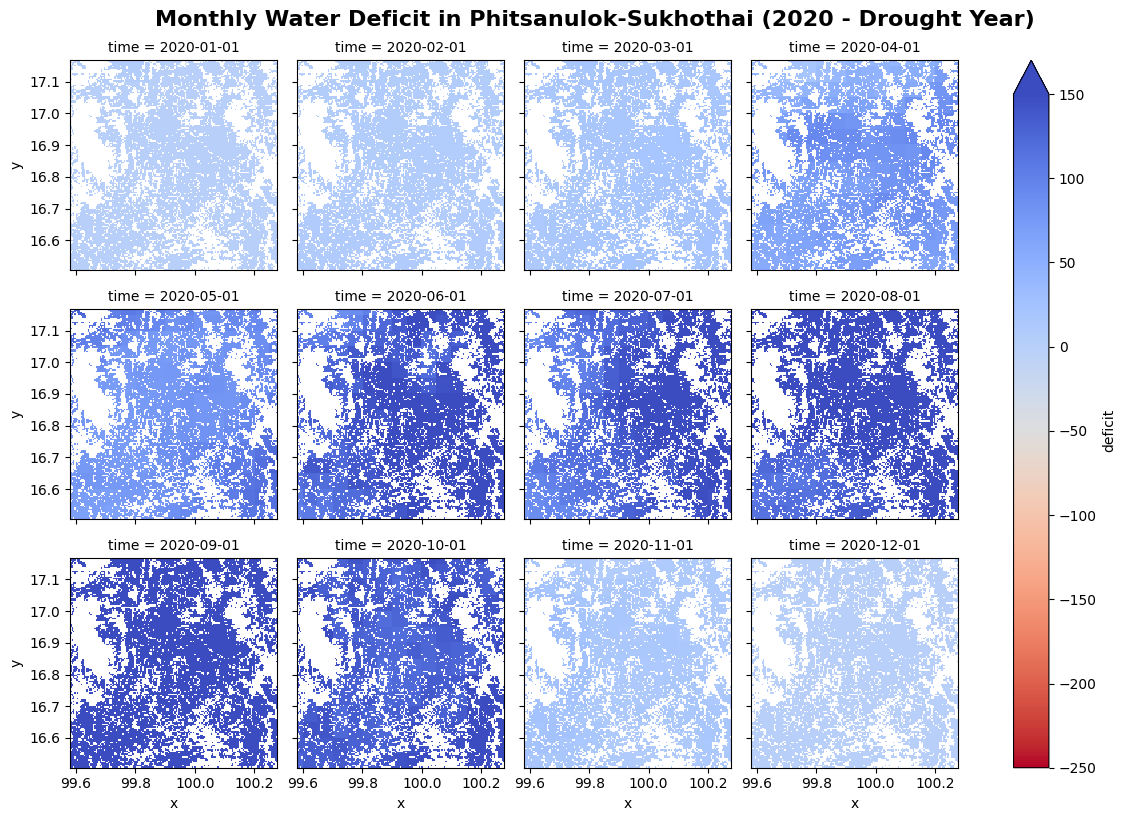


กำลังสร้างกราฟเปรียบเทียบ...


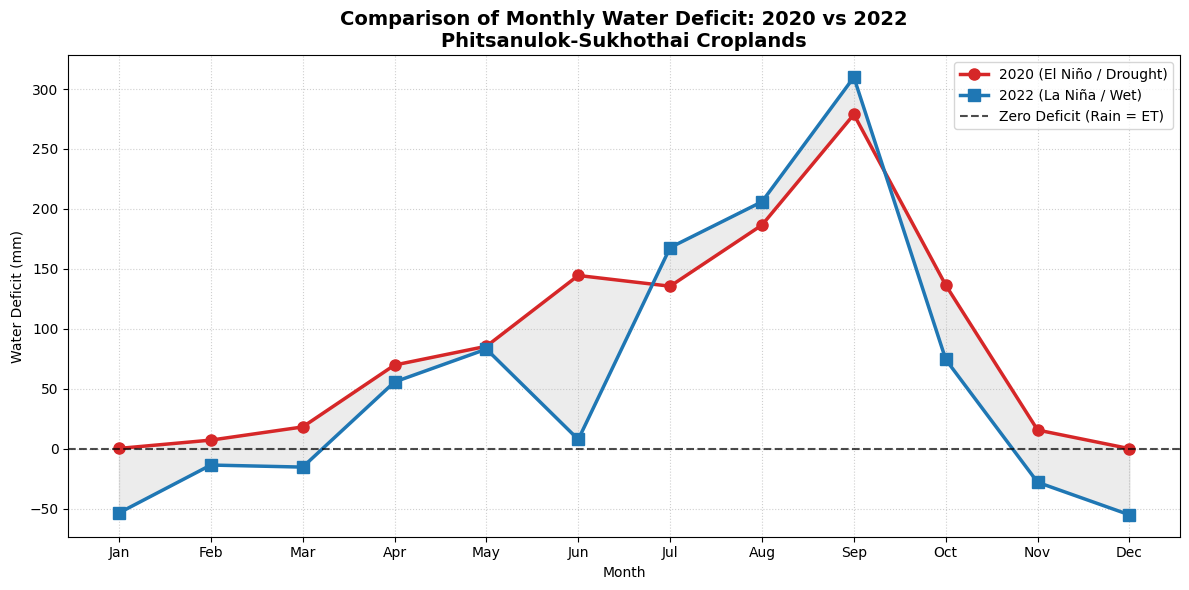

In [ ]:
import ee
import xarray as xr
import matplotlib.pyplot as plt
import shapely
from xee import helpers

# ========================================================
# 1. กำหนดขอบเขตพื้นที่ (Phitsanulok-Sukhothai)
# ========================================================
min_lon, min_lat = 99.58331572280514, 16.509823571011637
max_lon, max_lat = 100.2753723755851, 17.16654821808514

roi_ee = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
aoi_shapely = shapely.geometry.box(min_lon, min_lat, max_lon, max_lat)

# ========================================================
# 2. สร้างหน้ากากพื้นที่แปลงเกษตร (Cropland Mask)
# ========================================================
print("กำลังสร้างหน้ากากพื้นที่แปลงเกษตร (Cropland Mask)...")
modis_ndvi = ee.ImageCollection("MODIS/061/MOD13A1") \
    .filterDate('2022-01-01', '2022-04-30') \
    .filterBounds(roi_ee).select('NDVI')
ndvi_mask = modis_ndvi.max().multiply(0.0001).gt(0.5)

worldcover = ee.ImageCollection("ESA/WorldCover/v200").first()
crop_mask = worldcover.eq(40)
final_mask = ndvi_mask.And(crop_mask)

# ========================================================
# 3. ฟังก์ชันดึงข้อมูล Water Deficit รายเดือน (แก้ Error 0 Bands)
# ========================================================
year = 2020
months = ee.List.sequence(1, 12)

def calculateMonthlyDeficit(m):
    start = ee.Date.fromYMD(year, m, 1)
    end = start.advance(1, 'month')

    # สร้างภาพสำรอง (Dummy Image) เผื่อเดือนไหนเซิร์ฟเวอร์ดาวเทียมไม่มีข้อมูล
    dummy_et = ee.Image.constant(0).rename('ET').set('system:time_start', start.millis())
    dummy_pr = ee.Image.constant(0).rename('precipitation').set('system:time_start', start.millis())

    # ดึงข้อมูล ET และผสม Dummy
    et_col = ee.ImageCollection("MODIS/061/MOD16A2") \
        .filterDate(start, end).filterBounds(roi_ee).select('ET')
    et_month = et_col.merge(ee.ImageCollection([dummy_et])) \
        .sum().multiply(0.1)

    # ดึงข้อมูลปริมาณน้ำฝน (PR) และผสม Dummy
    pr_col = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY") \
        .filterDate(start, end).filterBounds(roi_ee).select('precipitation')
    pr_month = pr_col.merge(ee.ImageCollection([dummy_pr])) \
        .sum()

    # คำนวณ P - ET
    monthly_deficit = pr_month.subtract(et_month) \
        .updateMask(final_mask) \
        .set('system:time_start', start.millis()) \
        .rename('deficit')

    return monthly_deficit

monthly_col = ee.ImageCollection.fromImages(months.map(calculateMonthlyDeficit))

# ========================================================
# 4. ดึงข้อมูลเข้าสู่ Xarray (ผ่าน Xee Engine)
# ========================================================
print("กำลังเตรียมพารามิเตอร์ Grid และดึงข้อมูลปี 2020 เข้าสู่ Xarray (อาจใช้เวลาสักครู่)...")

grid_params = helpers.fit_geometry(
    geometry=aoi_shapely,
    grid_crs='EPSG:4326',
    grid_scale=(0.0045, -0.0045)
)

ds = xr.open_dataset(
    monthly_col,
    engine='ee',
    **grid_params
)

# ========================================================
# 5. พล็อตแผนที่แบบ FacetGrid 12 ช่อง
# ========================================================
print("กำลังพล็อตแผนที่...")

ds.deficit.plot(
    x='x', y='y',
    col='time', col_wrap=4,
    cmap='coolwarm_r',
    robust=True,
    vmin=-250, vmax=150,
    figsize=(12, 8)
)

plt.suptitle('Monthly Water Deficit in Phitsanulok-Sukhothai (2020 - Drought Year)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# ========================================================
# 7. พล็อตกราฟเปรียบเทียบ (Comparison Line Chart)
# ========================================================
print("\nกำลังสร้างกราฟเปรียบเทียบ...")
plt.figure(figsize=(12, 6))

# เส้นปี 2020 (สีแดง)
plt.plot(df_2020['month'], df_2020['deficit'],
         marker='o', color='#d62728', linewidth=2.5, markersize=8, label='2020 (El Niño / Drought)')

# เส้นปี 2022 (สีน้ำเงิน)
plt.plot(df_2022['month'], df_2022['deficit'],
         marker='s', color='#1f77b4', linewidth=2.5, markersize=8, label='2022 (La Niña / Wet)')

# ตีเส้นแนวนอน 0 (จุดสมดุลน้ำ)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero Deficit (Rain = ET)')

# แรเงาพื้นที่ระหว่าง 2 เส้น
plt.fill_between(df_2020['month'], df_2020['deficit'], df_2022['deficit'], color='gray', alpha=0.15)

# ตกแต่งกราฟ
plt.title('Comparison of Monthly Water Deficit: 2020 vs 2022\nPhitsanulok-Sukhothai Croplands', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Water Deficit (mm)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

💡 1.Color Scale

สมการที่เราใช้คือ Deficit = P (ฝน) - ET (พืชคายน้ำ)

🔴 สีแดง/ส้ม (ค่าติดลบ): ฝนตกน้อย แต่พืชคายน้ำเยอะ ➡ แปลว่า "มีการสูบน้ำชลประทานมาทำนาปรัง" พืชจึงเขียวชอุ่มและคายน้ำได้

🔵 สีน้ำเงิน (ค่าเป็นบวก): ฝนตกเยอะกว่าที่พืชต้องการ ➡ แปลว่า "มีน้ำเหลือเฟือ หรืออาจเกิดน้ำท่วม"

⚪ สีขาว/ฟ้าอ่อน (ค่าใกล้ 0): ไม่มีฝน และพืชก็ไม่ได้คายน้ำ ➡ แปลว่า "ทุ่งนาถูกทิ้งร้าง ดินแห้งแล้งไม่มีพืชปลูกอยู่เลย"
